In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [155]:
nvidia_data = (
    pd.read_csv("nvidia2.csv", index_col=0, parse_dates=True)
    .reset_index(drop=False)
    .reset_index(names="idx")
)
apple_data = pd.read_csv("apple.csv", index_col=0, parse_dates=True).reset_index(
    drop=False
)

In [156]:
nvidia_data.head()

,idx,Date,Price,Open,High,Low,Vol.,Change %
0,0,2025-12-31,186.50,189.57,190.56,186.49,120.10M,-0.55%
1,1,2025-12-30,187.54,188.24,188.99,186.93,97.69M,-0.36%
2,2,2025-12-29,188.22,187.71,188.76,185.91,120.01M,-1.21%
3,3,2025-12-26,190.53,189.92,192.69,188.00,139.74M,1.02%
4,4,2025-12-24,188.61,187.94,188.91,186.59,65.53M,-0.32%


In [69]:
# nvidia_data.sort_values(by="Open", ascending=True, inplace=True)
# nvidia_data.reset_index(inplace=True, drop=True)

In [157]:
boundary = 120
nvidia_data_f = nvidia_data.query(f"Open < {boundary}").sort_values(
    by="Open", ascending=True
)
nvidia_data_f.reset_index(inplace=True)

skladowe_spojne = {}
starters = nvidia_data_f["index"].sort_values().tolist()

while starters:
    current = starters.pop(0)
    skladowa = [current]

    while True:
        next_idx = current + 1
        if next_idx in starters:
            skladowa.append(next_idx)
            starters.remove(next_idx)
            current = next_idx
        else:
            break

    skladowe_spojne[skladowa[0]] = skladowa

skladowe_spojne

{162: [162,
  163,
  164,
  165,
  166,
  167,
  168,
  169,
  170,
  171,
  172,
  173,
  174,
  175,
  176,
  177,
  178,
  179,
  180,
  181,
  182,
  183,
  184,
  185,
  186,
  187,
  188,
  189,
  190,
  191,
  192,
  193],
 195: [195, 196, 197, 198, 199],
 201: [201, 202, 203, 204, 205, 206, 207, 208, 209],
 211: [211],
 228: [228, 229]}

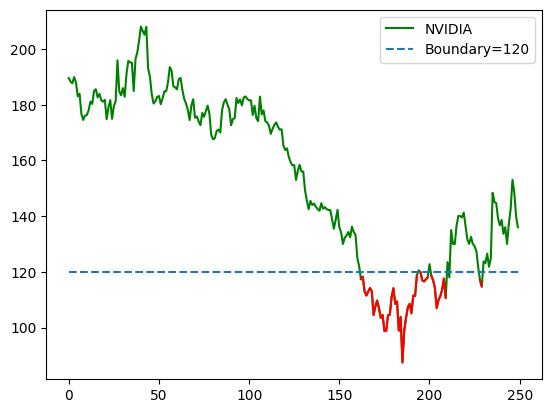

In [158]:
plt.plot(nvidia_data["Open"], label="NVIDIA", color="green")

for key in skladowe_spojne.keys():
    plt.plot(
        skladowe_spojne[key],
        nvidia_data.loc[skladowe_spojne[key], "Open"],
        #  marker='o',
        color="red",
    )
    # plt.show()

plt.hlines(
    boundary,
    xmin=0,
    xmax=len(nvidia_data),
    linestyle="--",
    label=f"Boundary={boundary}",
)

plt.legend()
plt.show()

In [73]:
# boundary = 120
# nvidia_data_f = nvidia_data.query(f"Open < {boundary}")
# nvidia_data_f.reset_index(inplace=True)

# skladowe_spojne = {}
# starters = nvidia_data_f["index"].sort_values().tolist()

# while starters:
#     current = starters.pop(0)
#     skladowa = [current]

#     while True:
#         next_idx = current + 1
#         if next_idx in starters:
#             skladowa.append(next_idx)
#             starters.remove(next_idx)
#             current = next_idx
#         else:
#             break

#     skladowe_spojne[skladowa[0]] = skladowa

# skladowe_spojne

In [74]:
# nvidia_data.sort_values(by="Open", ascending=True, inplace=True)
# nvidia_data.reset_index(inplace=True, drop=True)

In [106]:
nvidia_data.head(20)

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-12-31,186.50,189.57,190.56,186.49,120.10M,-0.55%
1,2025-12-30,187.54,188.24,188.99,186.93,97.69M,-0.36%
2,2025-12-29,188.22,187.71,188.76,185.91,120.01M,-1.21%
3,2025-12-26,190.53,189.92,192.69,188.00,139.74M,1.02%
4,2025-12-24,188.61,187.94,188.91,186.59,65.53M,-0.32%
5,2025-12-23,189.21,182.97,189.33,182.90,174.87M,3.01%
6,2025-12-22,183.69,183.92,184.16,182.35,129.06M,1.49%
7,2025-12-19,180.99,176.66,181.45,176.34,324.93M,3.93%
8,2025-12-18,174.14,174.53,176.15,171.82,176.10M,1.87%
9,2025-12-17,170.94,176.10,176.13,170.31,222.78M,-3.81%


In [39]:
# boundaries = np.linspace(nvidia_data["Open"].min(), nvidia_data["Open"].max(), num=50)

# filtracje = {}
# for t in boundaries[1:]:  # progi od drugiego punktu
#     nvidia_data_f = nvidia_data[nvidia_data["Open"] <= t].copy()
#     nvidia_data_f = nvidia_data_f.reset_index()  # kolumna 'index' = oryginalny indeks

#     starters = sorted(nvidia_data_f["index"].tolist())

#     skladowe_spojne = {}
#     while starters:
#         start = starters.pop(0)
#         current = start
#         skladowa = [start]
#         while starters and starters[0] == current + 1:
#             current = starters.pop(0)
#             skladowa.append(current)
#         skladowe_spojne[start] = skladowa

#     filtracje[t] = skladowe_spojne

,Date,Price,Open,High,Low,Vol.,Change %
185,2025-04-07,97.64,87.46,101.75,86.62,611.04M,3.53%
176,2025-04-21,96.91,98.77,99.44,95.04,288.50M,-4.51%
175,2025-04-22,98.89,98.78,99.81,97.28,241.00M,2.04%
183,2025-04-09,114.33,98.89,115.10,97.53,612.92M,18.72%
186,2025-04-04,94.31,98.91,100.13,92.11,532.27M,-7.36%


In [ ]:
boundaries = np.linspace(nvidia_data["Open"].min(), nvidia_data["Open"].max(), 10)
filtracje = {}
for i, boundary in enumerate(boundaries):
    nvidia_data_f = nvidia_data.query(f"Open <= {boundary} + 1").sort_values(
        by="Open", ascending=True
    ).reset_index()
    # nvidia_data_f.reset_index(inplace=True)

    skladowe_spojne = {}
    starters = nvidia_data_f["index"].tolist()

    while starters:
        current = starters.pop(0)
        skladowa = [current]

        while True:
            next_idx = current + 1
            if next_idx in starters:
                skladowa.append(next_idx)
                starters.remove(next_idx)
                current = next_idx
            else:
                break

        skladowe_spojne[skladowa[0]] = skladowa

    filtracje[boundary] = skladowe_spojne

key = list(filtracje[list(filtracje.keys())[1]].keys())
list(filtracje[list(filtracje.keys())[1]].keys())

[185, 176, 175, 183]

In [133]:
# filtracje[list(filtracje.keys())[4]]

In [138]:
persistance = {}

for id, key in enumerate(filtracje.keys()):
    persistance[f"F{id}"] = list(filtracje[key].keys())

In [139]:
pprint(persistance)

{'F0': [185],
 'F1': [185, 176, 175, 183],
 'F2': [185, 176, 175, 173, 169, 204, 209, 165, 164, 203],
 'F3': [185, 176, 175, 173, 169, 165, 164, 229, 228, 162, 227, 161, 160, 226],
 'F4': [185,
        176,
        175,
        173,
        169,
        165,
        164,
        229,
        228,
        162,
        227,
        161,
        160,
        226,
        225,
        243,
        152,
        222,
        221,
        241,
        151,
        147,
        249,
        150,
        220,
        239,
        146,
        238,
        248],
 'F5': [185,
        176,
        175,
        173,
        169,
        165,
        164,
        162,
        161,
        160,
        152,
        151,
        147,
        146,
        139,
        138,
        133,
        132,
        131,
        126],
 'F6': [185,
        176,
        175,
        173,
        169,
        165,
        164,
        162,
        161,
        160,
        152,
        151,
        147,
        146

In [161]:
boundaries = np.linspace(nvidia_data["Open"].min(), nvidia_data["Open"].max(), 10)

filtracje = {}
for boundary in boundaries:
    nvidia_data_f = nvidia_data.query(
        "Open <= @boundary + 1e-5"
    ).reset_index()  # kolumna 'index' = oryginalny indeks

    skladowe_spojne = {}
    starters = sorted(nvidia_data_f["index"].tolist())  # KLUCZOWE

    while starters:
        current = starters.pop(0)
        skladowa = [current]

        while True:
            next_idx = current + 1
            if next_idx in starters:
                skladowa.append(next_idx)
                starters.remove(next_idx)
                current = next_idx
            else:
                break

        skladowe_spojne[skladowa[0]] = skladowa

    filtracje[boundary] = skladowe_spojne

In [162]:
from pprint import pprint

pprint(filtracje)

{np.float64(87.46): {185: [185]},
 np.float64(100.86222222222221): {175: [175, 176], 183: [183], 185: [185, 186]},
 np.float64(114.26444444444445): {164: [164,
                                        165,
                                        166,
                                        167,
                                        168,
                                        169,
                                        170,
                                        171,
                                        172,
                                        173,
                                        174,
                                        175,
                                        176,
                                        177,
                                        178,
                                        179,
                                        180,
                                        181,
                                        182,
                              

In [119]:
persistance = {}

for id, key in enumerate(filtracje.keys()):
    persistance[f"F{id}"] = list(filtracje[key].keys())

In [120]:
persistance

{'F0': [185],
 'F1': [175, 183, 185],
 'F2': [164, 203, 209],
 'F3': [160, 226],
 'F4': [146, 150, 220, 238, 248],
 'F5': [126, 131],
 'F6': [80, 119],
 'F7': [7, 19, 21, 24, 47, 51, 65, 70, 88, 94, 96, 102, 107],
 'F8': [0, 28, 36, 44],
 'F9': [0]}

In [165]:
boundaries = np.linspace(nvidia_data["Open"].min(), nvidia_data["Open"].max(), 10)
filtracje = {}
for i, boundary in enumerate(boundaries):
    nvidia_data_f = (
        nvidia_data.query(f"Open <= {boundary} + 1")
        .sort_values(by="Open", ascending=True)
        .reset_index()
    )
    # nvidia_data_f.reset_index(inplace=True)

    skladowe_spojne = {}
    starters = nvidia_data_f["index"].tolist()

    while starters:
        current = starters.pop(0)
        skladowa = [current]

        while True:
            next_idx = current + 1
            if next_idx in starters:
                skladowa.append(next_idx)
                starters.remove(next_idx)
                current = next_idx
            else:
                break

        skladowe_spojne[skladowa[0]] = skladowa

    filtracje[boundary] = skladowe_spojne

key = list(filtracje[list(filtracje.keys())[1]].keys())
list(filtracje[list(filtracje.keys())[1]].keys())

[185, 176, 175, 183]

In [166]:
from pprint import pprint

pprint(filtracje)

{np.float64(87.46): {185: [185]},
 np.float64(100.86222222222221): {175: [175],
                                  176: [176],
                                  183: [183],
                                  185: [185, 186]},
 np.float64(114.26444444444445): {164: [164],
                                  165: [165, 166, 167, 168],
                                  169: [169, 170, 171, 172],
                                  173: [173, 174],
                                  175: [175],
                                  176: [176,
                                        177,
                                        178,
                                        179,
                                        180,
                                        181,
                                        182,
                                        183,
                                        184],
                                  185: [185, 186, 187, 188, 189, 190, 191, 192],
                        